# Expected Free Energy minimization for mobile robot navigation (IR beacon sensor)


### Joost Leliveld, last update: 06-02-2026  
Heavily inspired from Wouter Kouw

### Usecase:

A differential-drive robot moves on a plane and is observed by a **single fixed IR station**. The station reports a nonlinear measurement consisting of the robot's **bearing** (global angle from the station to the robot) and an **intensity** signal that decays with distance.

This provides a simple, explicit nonlinear observation model (via `atan2` and inverse-distance intensity), which is useful for studying when EFE1 and EFE2 diverge without camera calibration/detector complexity.


### Dynamics (differential-drive / unicycle model)

Consider a robot that moves according to the unicycle model with linear and angular velocity inputs:

$$z_k = \begin{bmatrix} x_k \\ y_k \\ \theta_k \end{bmatrix},\qquad
 u_k = \begin{bmatrix} v_k \\ \omega_k \end{bmatrix}.$$

The discrete-time dynamics are

$$
\begin{aligned}
 x_k &= x_{k-1} + v_k\,\Delta t\,\cos(\theta_{k-1}) \\
 y_k &= y_{k-1} + v_k\,\Delta t\,\sin(\theta_{k-1}) \\
 \theta_k &= \theta_{k-1} + \omega_k\,\Delta t
\end{aligned}
\qquad +\; q_k\,.
$$


Process noise is white, $q_k \sim \mathcal{N}(0,Q)$.

For the notebook we use a simple diagonal model in $[x,y,\theta]$:

$$
Q =
\begin{bmatrix}
\sigma_x^2 & 0 & 0 \\
0 & \sigma_y^2 & 0 \\
0 & 0 & \sigma_\theta^2
\end{bmatrix}\, .
$$

These values are *placeholders* and should be replaced with estimates from simulation or real data.


### Observations: fixed IR station (bearing + intensity)

A static IR station at known position $b = (b_x, b_y)$ observes the robot and outputs a 2D measurement:

$$o_k 	riangleq begin{bmatrix} \phi_k \ I_k \end{bmatrix} \in \mathbb{R}^2,$$

where:
- $\phi_k$ is the global bearing angle from the station to the robot,
- $I_k$ is an IR intensity proxy that decays with distance.

The observation model is nonlinear:

$$o_k = g(z_k) + r_k,\qquad r_k \sim \mathcal{N}(0,R).$$

Using the robot position $p_k = (x_k, y_k)$ and station position $b$, define

$$
\Delta x_k = x_k - b_x,\qquad \Delta y_k = y_k - b_y,\qquad r_k^2 = \Delta x_k^2 + \Delta y_k^2.
$$

We use the measurement function

$$
g(z_k) =
begin{bmatrix}
\operatorname{atan2}(\Delta y_k, \Delta x_k) \alpha,(r_k^2 + c)^{-1}
\end{bmatrix},
$$

with constants $alpha > 0$ and $c > 0$.

This model is nonlinear because:
- the bearing uses $\operatorname{atan2}(\cdot,\cdot)$,
- the intensity uses inverse distance squared (regularized by $c$).

> Practical note: bearing has a branch cut at $\pm\pi$. In this notebook we place the station and trajectory so the experiment stays away from that discontinuity.


### Probabilistic model

We use a probabilistic state-space model with nonlinear unicycle dynamics and a nonlinear IR-station observation model:

$$egin{align}
p(z_0) &= \mathcal{N}(z_0 \mid m_0, S_0) \
p(z_k \mid z_{k-1}, u_k) &= \mathcal{N}(z_k \mid f(z_{k-1}, u_k), Q) \
p(o_k \mid z_k) &= \mathcal{N}(o_k \mid g(z_k), R)\, .
\end{align}$$

Here, $z_k \in \mathbb{R}^3$ is the unicycle state and $o_k = [\phi_k, I_k]^	op$ is the IR-station measurement.


### Gaussian approximation to likelihood

Because $g(\cdot)$ is nonlinear, the likelihood $p(o_k \mid z_k)$ is generally non-Gaussian as a function of $z_k$.

Using the IR-station observation model,

$$
g(z_k)=
egin{bmatrix}
\operatorname{atan2}(y_k-b_y,\,x_k-b_x) \
lpha\left((x_k-b_x)^2 + (y_k-b_y)^2 + c
ight)^{-1}
\end{bmatrix},
$$

the likelihood is (up to a normalization constant)

$$
p(o_k \mid z_k)
=

rac{1}{\sqrt{(2\pi)^2 \det R}}
\exp\!\Big(-	frac12 (o_k-g(z_k))^	op R^{-1}(o_k-g(z_k))\Big).
$$

Since $g(z_k)$ is nonlinear, we approximate the joint $(z_k, o_k)$ as a Gaussian:

$$p(o_k, z_k) pprox \mathcal{N}\!\left(
egin{bmatrix} z_k \ o_k \end{bmatrix}
\Bigg|\,
egin{bmatrix} m_k \ \mu_k \end{bmatrix},
egin{bmatrix} S_k & \Gamma_k \ \Gamma_k^{	op} & \Sigma_k \end{bmatrix}

ight)\, .$$

Because this joint is Gaussian, conditioning yields an approximate Gaussian likelihood. The parameters $(\mu_k, \Sigma_k, \Gamma_k)$ are obtained by a Gaussian approximation method:
first-order Taylor (ET1/EFE1), second-order Taylor (ET2/EFE2), or sigma-point (UT) approximation.


## Posterior predictive

The posterior predictive distribution of the observation is obtained by marginalizing
over the latent state:

$$
\begin{align}
p(o_k \mid o_{1:k-1})
&= \int p(o_k \mid z_k)\, p(z_k \mid o_{1:k-1}) \, dz_k \tag{1}\\
&= \int \mathcal N\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix}
S_k & \Gamma_k \\
\Gamma_k^\top & \Sigma_k
\end{bmatrix}
\right) dz_k \tag{2}\\
&= \mathcal N(o_k \mid \mu_k, \Sigma_k). \tag{3}
\end{align}
$$

That is, marginalizing a joint Gaussian yields a Gaussian predictive distribution
with mean $\mu_k$ and covariance $\Sigma_k$.


## Planning and control

### Expected Free Energy (EFE) objective

The Expected Free Energy objective for a single time step is given by

$$
\mathcal J_k(u_t)
=
\mathcal C
+
\frac{1}{2}\,\mathrm{tr}\!\left(S_*^{-1}(\Sigma_t + \Sigma_\star)\right)
+
\frac{1}{2}\,\ln
\frac{\left| \Sigma_t - \Gamma_t^\top S_t^{-1} \Gamma_t \right|}
{\left| \Sigma_t \right|}. \tag{1}
$$

The first term encodes the expected risk, while the log-determinant term captures
expected ambiguity through the conditional observation covariance.

### Horizon-based control optimization

For a planning horizon of $T$ steps, the optimal control sequence is obtained as

$$
\begin{align}
\hat u
&= \arg\max_{u \in \mathcal U} q^\star(u) \tag{1}\\
&= \arg\min_{u \in \mathcal U}
\sum_{t=1}^{T} \mathcal J_t(u_t)
- \ln p(u_t). \tag{2}
\end{align}
$$


In [81]:
from pathlib import Path
import sys

CWD = Path.cwd()
ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
sys.path.insert(0, str(ROOT / "scripts"))
ANIM_DIR = ROOT / "scripts" / "animations"
ANIM_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "scripts" / "figures"
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from tqdm import tqdm

from robots import UnicycleBot, update_unicycle
from botnav_efe_helpers import (
    UnicycleEFEAgent,
    predict_unicycle,
    correct,
    evidence,
    planned_trajectory_unicycle,
)
from botnav_efe_jax import bind_unicycle_agent_jax, make_unicycle_valgrad_fn


In [82]:
# Matplotlib settings
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3

def plot_cov_ellipse(ax, mean, cov, n_std=1, color='blue', alpha=0.3, linewidth=0):
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    order = eigenvals.argsort()[::-1]
    eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

    angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvals)

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  color=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)


In [83]:
# =========================
# EXPERIMENT SETUP (IR beacon station) - comparison mode
# =========================

# --- Time ---
Δt = 0.2
len_trial = 120
len_horizon = 6  # shorter horizon to make method differences more visible

# --- IR station sensor geometry ---
beacon_xy = np.array([0.08, 0.25])  # near (but not exactly on) direct route
ir_alpha = 1.0
ir_offset = 0.08  # stronger nonlinearity than 0.10


def g(x):
    dx = float(x[0] - beacon_xy[0])
    dy = float(x[1] - beacon_xy[1])
    r2 = dx * dx + dy * dy
    phi = np.arctan2(dy, dx)
    intensity = ir_alpha / (r2 + ir_offset)
    return np.array([np.sin(phi), np.cos(phi), intensity], dtype=float)



sigma_process_xy = 0.08
sigma_process_theta = np.deg2rad(5.0)
Q = np.diag([sigma_process_xy**2, sigma_process_xy**2, sigma_process_theta**2])

sigma_sin = 0.06
sigma_cos = 0.06
sigma_intensity = 0.06
R = np.diag([sigma_sin**2, sigma_cos**2, sigma_intensity**2])


# --- Control limits ---
v_lims = (0.0, 0.22)
w_lims = (-1.0, 1.0)
η = 0.0

# --- Start / goal ---
start_xy = np.array([0.0, -1.0])
goal_xy = np.array([0.3, 1.0])

theta_0 = np.arctan2(goal_xy[1] - start_xy[1], goal_xy[0] - start_xy[0])
z_0 = np.array([start_xy[0], start_xy[1], theta_0])
z_star = np.array([goal_xy[0], goal_xy[1], theta_0])

# --- Goal observation / prior (looser => less goal-dominated) ---
goal_obs = g(z_star)
goal_sigma_sin = 0.08
goal_sigma_cos = 0.08
goal_sigma_intensity = 0.10
goal = (goal_obs, np.diag([goal_sigma_sin**2, goal_sigma_cos**2, goal_sigma_intensity**2]))

# --- Initial belief uncertainty ---
sigma_init_xy = 0.5
sigma_init_theta = np.deg2rad(12.0)
S_0 = np.diag([sigma_init_xy**2, sigma_init_xy**2, sigma_init_theta**2])

# --- Robot + Agent (must be rebuilt after len_horizon/Q/R/goal changes) ---
fbot = UnicycleBot(g, Q=Q, R=R, dt=Δt, control_lims=(v_lims, w_lims))
agent = UnicycleEFEAgent(goal, g, Q=Q, R=R, eta=η, dt=Δt, time_horizon=len_horizon)

print("Start :", start_xy, "theta=", theta_0)
print("Goal  :", goal_xy, "theta=", theta_0)
print("Beacon:", beacon_xy)
print("Goal obs [sin(phi), cos(phi), intensity]:", goal_obs)
print("len_horizon:", len_horizon, "| agent.time_horizon:", agent.time_horizon)


Start : [ 0. -1.] theta= 1.4219063791853994
Goal  : [0.3 1. ] theta= 1.4219063791853994
Beacon: [0.08 0.25]
Goal obs [sin(phi), cos(phi), intensity]: [0.95956898 0.28147357 1.44738747]
len_horizon: 6 | agent.time_horizon: 6


In [84]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

params_j = bind_unicycle_agent_jax(agent)

beacon_xy_j = jnp.array(beacon_xy, dtype=jnp.float64)

def g_jax(x):
    x = jnp.asarray(x)
    dx = x[0] - beacon_xy_j[0]
    dy = x[1] - beacon_xy_j[1]
    r2 = dx * dx + dy * dy
    phi = jnp.arctan2(dy, dx)
    intensity = ir_alpha / (r2 + ir_offset)
    return jnp.stack([jnp.sin(phi), jnp.cos(phi), intensity])



In [85]:
def animate_run(z_sim, z_est, z_pln, label, filename, xl, yl):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")

    def animate_frame(k):
        ax.clear()
        ax.set_xlim(xl)
        ax.set_ylim(yl)
        ax.set_aspect('equal')
        ax.set_title(f"{label}: {k+1}/{len_trial}")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.grid(alpha=0.25)

        ax.scatter([beacon_xy[0]], [beacon_xy[1]], color="orange", marker="*", label="IR station", s=80)
        ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
        ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

        ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)
        ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
        plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                         n_std=1, color="purple", alpha=0.3, linewidth=0)

        ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
        for j in range(len_horizon):
            plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                             n_std=1, color="orange", alpha=0.3, linewidth=0)

        if k == 2:
            ax.legend(loc='upper left')

    anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=1000, repeat=False)
    anim.save(str(ANIM_DIR / filename), writer=PillowWriter(fps=1))
    plt.close()


In [86]:
def plot_run(z_sim, z_est, label, xl=None, yl=None, save_path=None):
    n_steps = z_sim.shape[1]

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    ax.set_facecolor("#fafafa")

    # Auto-limits include trajectory + station + goal
    if xl is None or yl is None:
        xs = np.concatenate([z_sim[0, :], z_est[0][0, :], np.array([z_star[0], beacon_xy[0]])])
        ys = np.concatenate([z_sim[1, :], z_est[0][1, :], np.array([z_star[1], beacon_xy[1]])])
        margin = 0.2
        xl = [xs.min() - margin, xs.max() + margin]
        yl = [ys.min() - margin, ys.max() + margin]

    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.grid(alpha=0.18, linewidth=0.8)

    # Background: range isocontours around the station
    for rad in [0.25, 0.5, 0.75, 1.0, 1.25]:
        ax.add_patch(
            plt.Circle(
                beacon_xy, rad, fill=False, ls="--", lw=0.8,
                color="orange", alpha=0.22, zorder=0
            )
        )

    # Covariance ellipses (decimated to reduce clutter)
    stride = max(1, n_steps // 35)
    idxs = list(range(1, n_steps, stride))  # skip j=0 (often huge and obscures start)
    if (n_steps - 1) not in idxs:
        idxs.append(n_steps - 1)

    for j in idxs:
        plot_cov_ellipse(
            ax,
            z_est[0][0:2, j],
            z_est[1][0:2, 0:2, j],
            n_std=1,
            color="purple",
            alpha=0.07,
            linewidth=0,
        )

    # Trajectories
    ax.plot(z_sim[0, :], z_sim[1, :], c="blue", lw=2.6, label="true", zorder=3)
    ax.plot(z_est[0][0, :], z_est[0][1, :], c="purple", lw=2.3, label="inferred", zorder=3)

    # Key markers (draw last so they stay visible)
    ax.scatter([z_sim[0, 0]], [z_sim[1, 0]], color="green", marker="D", s=70,
               edgecolors="black", linewidths=0.5, label="start", zorder=5)
    ax.scatter([z_star[0]], [z_star[1]], color="red", s=70,
               edgecolors="black", linewidths=0.4, label="goal", zorder=5)
    ax.scatter([beacon_xy[0]], [beacon_xy[1]], color="orange", marker="*", s=120,
               edgecolors="black", linewidths=0.4, label="IR station", zorder=5)

    ax.set_title(label, loc="left", fontweight="bold")

    # Legend outside the axes (no overlap)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # remove duplicates, preserve last style
    ax.legend(
        by_label.values(), by_label.keys(),
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        borderaxespad=0.0
    )

    # Make room for outside legend
    fig.subplots_adjust(right=0.78)

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()



## Model: EFE(ET2)

In [87]:
# assumes params_j and g_jax already defined in the JAX setup cell
valgrad = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=True, mode="fwd")

z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE2 = np.zeros(len_trial)
J_EFE2 = np.zeros(len_trial)

z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE2 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence
    F_EFE2[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")
    J_EFE2[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return float(val)

    def grad_u(u):
        _, grad = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.asarray(grad, dtype=float)
        

    x0 = np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])
    result = minimize(
        f,
        x0,
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )


    # Extract minimizing control
    policy = result.x.reshape((len_horizon, 2)).T
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE2 Experiment:   0%|          | 0/119 [00:00<?, ?it/s]

EFE2 Experiment: 100%|██████████| 119/119 [00:14<00:00,  8.13it/s]


In [88]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE2",
    filename="irbeacon-experiment-EFE2-path.gif",
    xl=xl,
    yl=yl,
)


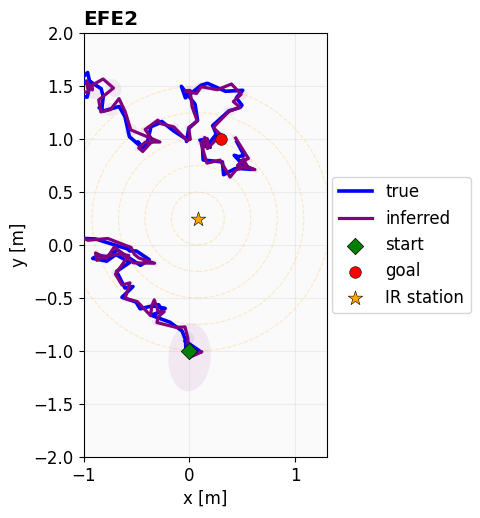

In [89]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE2", xl=xl, yl=yl, save_path=FIG_DIR / "irbeacon-experiment-EFE2-zoom.png")



In [90]:
# JAX val+grad for EFE1 (forward-mode)
valgrad_efe1 = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET1", add_ambiguity=True, mode="fwd")

# Preallocate
z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE1 = np.zeros(len_trial)
J_EFE1 = np.zeros(len_trial)

z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE1 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k - 1], u_sim[:, k - 1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k - 1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")

    # Compute model evidence
    F_EFE1[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")
    J_EFE1[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return float(val)

    def grad_u(u):
        _, grad = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.asarray(grad, dtype=float)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 200, "maxfun": 2000, "ftol": 1e-6},
    )

    # Extract minimizing control (optimizer is time-major [v1,w1,v2,w2,...], planner uses (2, T))
    policy = result.x.reshape((len_horizon, 2)).T
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET1")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE1 Experiment: 100%|██████████| 119/119 [00:06<00:00, 17.05it/s]


In [91]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE1",
    filename="irbeacon-experiment-EFE1-path.gif",
    xl=xl,
    yl=yl,
)


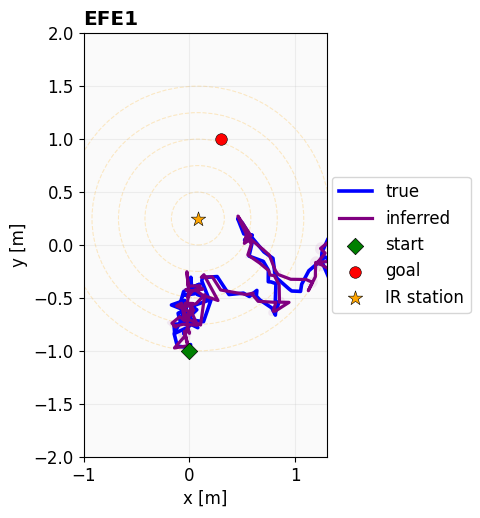

In [92]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE1", xl=xl, yl=yl, save_path=FIG_DIR / "irbeacon-experiment-EFE1-zoom.png")



In [93]:
# JAX val+grad for EFER (ET2, no ambiguity)
valgrad_efer = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=False, mode="fwd")

# Preallocate
z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFER = np.zeros(len_trial)
J_EFER = np.zeros(len_trial)

# Initialize first estimate (avoids line to origin)
z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFER Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence (Julia uses corrected + ET2)
    F_EFER[k] = evidence(agent, y_sim[:, k], m_k, S_k, approx="ET2")
    J_EFER[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract 
    policy = result.x.reshape((len_horizon, 2)).T
    u_sim[:, k] = policy[:, 0]


    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFER Experiment: 100%|██████████| 119/119 [00:18<00:00,  6.38it/s]


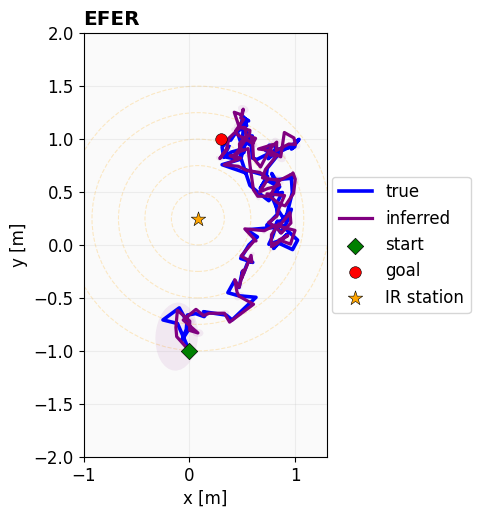

In [94]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFER", xl=xl, yl=yl, save_path=FIG_DIR / "irbeacon-experiment-EFER-zoom.png")


In [95]:
tF_EFE2 = np.sum(F_EFE2)
tF_EFE1 = np.sum(F_EFE1)
tF_EFER = np.sum(F_EFER)

print(f"F EFE2 = {tF_EFE2}")
print(f"F EFE1 = {tF_EFE1}")
print(f"F EFER = {tF_EFER}")


F EFE2 = -291.31265458303
F EFE1 = -289.32858717756386
F EFER = -489.3613075755712


In [96]:
tJ_EFE2 = np.sum(J_EFE2)
tJ_EFE1 = np.sum(J_EFE1)
tJ_EFER = np.sum(J_EFER)

print(f"Total goal prior -log-likelihood EFE2 = {tJ_EFE2}")
print(f"Total goal prior -log-likelihood EFE1 = {tJ_EFE1}")
print(f"Total goal prior -log-likelihood EFER = {tJ_EFER}")

Total goal prior -log-likelihood EFE2 = 17558.358144837486
Total goal prior -log-likelihood EFE1 = 30613.86181328956
Total goal prior -log-likelihood EFER = 12460.817605358232


In [97]:
perf_EFE2 = np.sum(F_EFE2) + np.sum(J_EFE2)
perf_EFE1 = np.sum(F_EFE1) + np.sum(J_EFE1)
perf_EFER = np.sum(F_EFER) + np.sum(J_EFER)

print(f"Performance EFE2 = {perf_EFE2}")
print(f"Performance EFE1 = {perf_EFE1}")
print(f"Performance EFER = {perf_EFER}")

Performance EFE2 = 17267.045490254455
Performance EFE1 = 30324.533226112
Performance EFER = 11971.45629778266


EFE1: 157.2s | final dist mean=0.436 std=0.330
EFER: 236.9s | final dist mean=0.410 std=0.340
EFE2: 311.3s | final dist mean=0.419 std=0.325


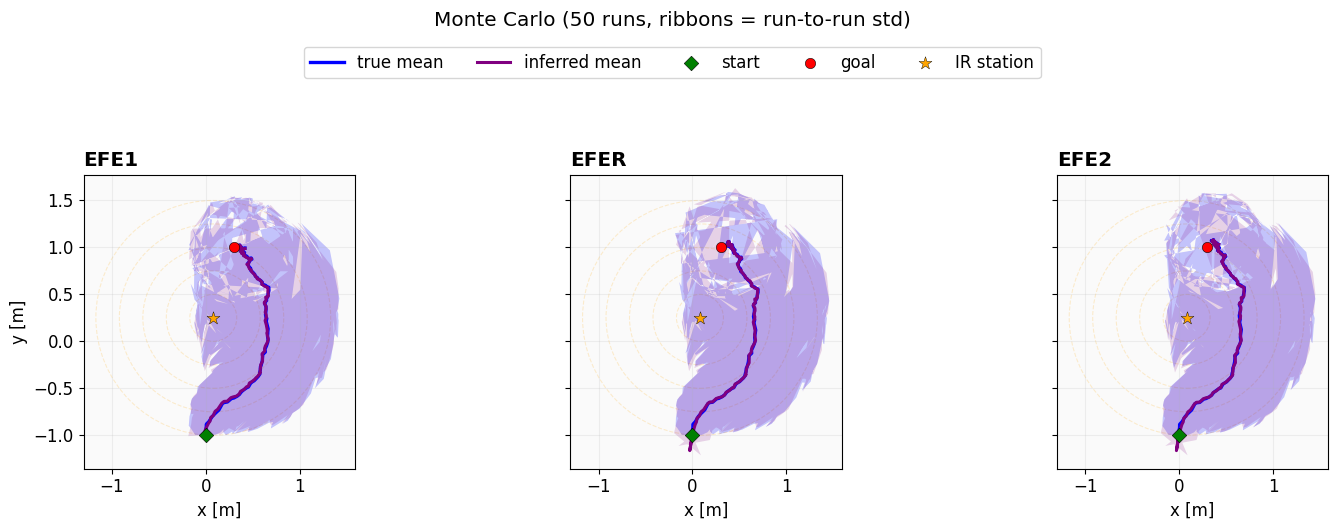

In [98]:
# --- Monte Carlo run + mean/spread plots (EFE1, EFER, EFE2) for IR station sensor ---

from time import perf_counter

n_runs = 50
seed0 = 0

# MC-specific speed knobs (safe to relax for plotting)
mc_maxiter = 60
mc_maxfun = 600
use_sem = False   # False => plot run-to-run std (more visible differences)
grad_mode = "rev" # often faster than "fwd" for larger len_horizon (e.g., 10)

def run_mc(approx, add_ambiguity, n_runs=50, seed0=0, maxiter=60, maxfun=600, grad_mode="rev"):
    true_runs = np.zeros((n_runs, len_trial, 2))
    est_runs = np.zeros((n_runs, len_trial, 2))

    valgrad = make_unicycle_valgrad_fn(
        params_j, g_jax, approx=approx, add_ambiguity=add_ambiguity, mode=grad_mode
    )
    bounds = [v_lims, w_lims] * len_horizon

    for r in range(n_runs):
        np.random.seed(seed0 + r)

        z_sim = np.zeros((3, len_trial))
        y_sim = np.zeros((agent.Dy, len_trial))
        u_sim = np.zeros((2, len_trial))
        z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))

        z_sim[:, 0] = z_0
        z_est[0][:, 0] = m_0
        z_est[1][:, :, 0] = S_0

        m_kmin1 = m_0
        S_kmin1 = S_0
        policy = np.zeros((2, len_horizon))  # planner layout: (2, T)

        for k in range(1, len_trial):
            # Environment
            y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k - 1], u_sim[:, k - 1])

            # State estimation
            m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k - 1])
            m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx=approx)

            # Store estimate
            z_est[0][:, k] = m_k
            z_est[1][:, :, k] = S_k

            def f(u):
                val, _ = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k))
                return float(val)

            def grad_u(u):
                _, grad = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k))
                return np.asarray(grad, dtype=float)

            # Warm-start from previous policy (time-major flat: [v1,w1,v2,w2,...])
            if k == 1:
                x0 = np.zeros(2 * len_horizon)
            else:
                x0 = np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])

            result = minimize(
                f,
                x0,
                jac=grad_u,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": maxiter, "maxfun": maxfun, "ftol": 1e-6},
            )

            # Optimizer output is time-major; planner uses (2, T)
            policy = result.x.reshape((len_horizon, 2)).T
            u_sim[:, k] = policy[:, 0]

            m_kmin1 = m_k
            S_kmin1 = S_k

        true_runs[r] = z_sim[:2].T
        est_runs[r] = z_est[0][:2].T

    return true_runs, est_runs


def plot_ribbon(ax, x_mean, y_mean, x_spread, y_spread, color, alpha=0.2):
    # Ribbon in local normal direction
    dx = np.gradient(x_mean)
    dy = np.gradient(y_mean)
    norm = np.sqrt(dx**2 + dy**2) + 1e-9
    nx = -dy / norm
    ny = dx / norm
    r = np.sqrt(x_spread**2 + y_spread**2)

    x_upper = x_mean + nx * r
    y_upper = y_mean + ny * r
    x_lower = x_mean - nx * r
    y_lower = y_mean - ny * r

    ax.fill(
        np.concatenate([x_upper, x_lower[::-1]]),
        np.concatenate([y_upper, y_lower[::-1]]),
        color=color,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


methods = [
    ("EFE1", "ET1", True),
    ("EFER", "ET2", False),
    ("EFE2", "ET2", True),
]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), sharex=True, sharey=True)

goal_xy_plot = np.asarray(z_star[:2], dtype=float)

for i, (ax, (title, approx, add_amb)) in enumerate(zip(axes, methods)):
    t0 = perf_counter()
    true_runs, est_runs = run_mc(
        approx, add_amb, n_runs=n_runs, seed0=seed0,
        maxiter=mc_maxiter, maxfun=mc_maxfun, grad_mode=grad_mode
    )
    elapsed = perf_counter() - t0

    # Mean trajectories
    true_mean = true_runs.mean(axis=0)
    est_mean = est_runs.mean(axis=0)

    # Spread: std (or SEM if use_sem=True)
    denom = np.sqrt(n_runs) if use_sem else 1.0
    true_spread = true_runs.std(axis=0, ddof=1) / denom
    est_spread = est_runs.std(axis=0, ddof=1) / denom

    # Optional numeric summary: final true distance to goal
    final_goal_dist = np.linalg.norm(true_runs[:, -1, :] - goal_xy_plot[None, :], axis=1)
    print(
        f"{title}: {elapsed:.1f}s | final dist mean={final_goal_dist.mean():.3f} "
        f"std={final_goal_dist.std(ddof=1):.3f}"
    )

    ax.set_facecolor("#fafafa")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    if i == 0:
        ax.set_ylabel("y [m]")
    ax.grid(alpha=0.18, linewidth=0.8)

    # Range isocontours for geometry intuition
    for rad in [0.25, 0.5, 0.75, 1.0, 1.25]:
        ax.add_patch(
            plt.Circle(
                beacon_xy, rad, fill=False, ls="--", lw=0.8,
                color="orange", alpha=0.18, zorder=0
            )
        )

    # Ribbons
    plot_ribbon(
        ax, true_mean[:, 0], true_mean[:, 1], true_spread[:, 0], true_spread[:, 1],
        color="blue", alpha=0.22
    )
    plot_ribbon(
        ax, est_mean[:, 0], est_mean[:, 1], est_spread[:, 0], est_spread[:, 1],
        color="purple", alpha=0.16
    )

    # Mean trajectories
    ax.plot(true_mean[:, 0], true_mean[:, 1], color="blue", lw=2.4, label="true mean", zorder=3)
    ax.plot(est_mean[:, 0], est_mean[:, 1], color="purple", lw=2.2, label="inferred mean", zorder=3)

    # Key markers
    ax.scatter([z_0[0]], [z_0[1]], color="green", marker="D", s=55,
               edgecolors="black", linewidths=0.4, label="start", zorder=5)
    ax.scatter([z_star[0]], [z_star[1]], color="red", s=55,
               edgecolors="black", linewidths=0.4, label="goal", zorder=5)
    ax.scatter([beacon_xy[0]], [beacon_xy[1]], color="orange", marker="*", s=95,
               edgecolors="black", linewidths=0.3, label="IR station", zorder=5)

# Figure-level legend outside (not over data)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=True,
)

spread_label = "SEM" if use_sem else "run-to-run std"
fig.suptitle(f"Monte Carlo ({n_runs} runs, ribbons = {spread_label})", y=1.10)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
